# Module 12 — Solutions: Time-Delay Cosmography & the Mass-Sheet Degeneracy

Worked answers to the five exercises in [`Modules/12_Time_Delay_Cosmography_MSD/`](../Modules/12_Time_Delay_Cosmography_MSD/12_time_delay_cosmography_msd.ipynb). Read the module first; this notebook assumes you've internalised the MSD derivation, the $H_0$–$\gamma'$ banana topology, and the TDCOSMO methodology overview.

All math derivations below are **symbolically verified** — the MSD identities re-derived in Exercise 1 are also a textbook result (S92 §11; Falco, Gorenstein & Shapiro 1985). Numerical work is **read-only** on `Examples/quad_time_delay/results/phase_2_h0_free/samples.csv` plus a small astropy cosmology calculation for Exercise 3.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

QTD_RESULTS = Path("../Examples/quad_time_delay/results")
PHASE_2 = QTD_RESULTS / "phase_2_h0_free"

%matplotlib inline
print(f"phase_2 artifacts present: {sorted(p.name for p in PHASE_2.iterdir())}")

phase_2 artifacts present: ['corner.pdf', 'fit_subplot.png', 'galaxies.png', 'info.txt', 'model_results.txt', 'samples.csv', 'samples_summary.json', 'summary.json']


---

## Exercise 1 — Re-derive the MSD

> Starting from $\kappa(\theta) \to \lambda \kappa(\theta) + (1-\lambda)$, derive the transformations of $\boldsymbol{\alpha}$, $\beta$, $\tau$, $\Delta t_{ij}$, and (assuming the observed delays are fixed) $H_0$. Show that flux ratios are MSD-invariant to first order.

### Solution

**Convergence transformation (given).**
$$\kappa(\theta) \;\longrightarrow\; \kappa_\lambda(\theta) = \lambda\,\kappa(\theta) + (1-\lambda).$$

**Deflection.** The 2D deflection from a convergence field is $\boldsymbol{\alpha}(\theta) = (1/\pi)\int d^2\theta'\,\kappa(\theta')\,(\theta-\theta')/|\theta-\theta'|^2$. For a uniform sheet $\kappa_0 = (1-\lambda)$, the deflection at any point inside is $\boldsymbol{\alpha}_\text{sheet}(\theta) = (1-\lambda)\,\theta$ (radial outward, linear in $\theta$). By linearity,
$$\boldsymbol{\alpha}_\lambda(\theta) = \lambda\,\boldsymbol{\alpha}(\theta) + (1-\lambda)\,\theta.$$

**Source position (lens equation).**
$$\beta_\lambda = \theta - \boldsymbol{\alpha}_\lambda(\theta) = \theta - \lambda\boldsymbol{\alpha}(\theta) - (1-\lambda)\,\theta = \lambda\,(\theta - \boldsymbol{\alpha}(\theta)) = \lambda\,\beta.$$

Image positions $\theta_i$ are **fixed** (we do not transform them); only the *inferred* source position rescales by $\lambda$.

**Lensing potential.** $\nabla^2\psi = 2\kappa$, so $\psi_\lambda(\theta) = \lambda\,\psi(\theta) + \tfrac{1}{2}(1-\lambda)\,|\theta|^2$ (up to a constant the Fermat potential ignores).

**Fermat potential.**
$$\tau_\lambda(\theta;\beta_\lambda) = \tfrac{1}{2}|\theta-\beta_\lambda|^2 - \psi_\lambda(\theta).$$
Substitute $\beta_\lambda = \lambda\beta$ and $\psi_\lambda$:
$$\tau_\lambda = \tfrac{1}{2}|\theta - \lambda\beta|^2 - \lambda\psi(\theta) - \tfrac{1}{2}(1-\lambda)|\theta|^2.$$
Expand $|\theta-\lambda\beta|^2 = |\theta|^2 - 2\lambda\,\theta\!\cdot\!\beta + \lambda^2|\beta|^2$:
$$\tau_\lambda = \tfrac{1}{2}|\theta|^2 - \lambda\,\theta\!\cdot\!\beta + \tfrac{1}{2}\lambda^2|\beta|^2 - \lambda\psi(\theta) - \tfrac{1}{2}(1-\lambda)|\theta|^2$$
$$= \tfrac{1}{2}\lambda|\theta|^2 - \lambda\,\theta\!\cdot\!\beta + \tfrac{1}{2}\lambda^2|\beta|^2 - \lambda\psi(\theta).$$
Now $\tfrac{1}{2}\lambda|\theta|^2 = \lambda\bigl[\tfrac{1}{2}|\theta|^2\bigr]$ and $\lambda\,\theta\!\cdot\!\beta = \lambda\,(\theta\!\cdot\!\beta)$, so
$$\tau_\lambda = \lambda\,\bigl[\tfrac{1}{2}|\theta|^2 - \theta\!\cdot\!\beta + \tfrac{1}{2}\lambda|\beta|^2 - \psi(\theta)\bigr].$$
Compare to $\tau = \tfrac{1}{2}|\theta-\beta|^2 - \psi(\theta) = \tfrac{1}{2}|\theta|^2 - \theta\!\cdot\!\beta + \tfrac{1}{2}|\beta|^2 - \psi(\theta)$. Differences in $\tau$ between two images $i, j$ at the same source $\beta$ have the $|\beta|^2$ term cancel, so
$$\tau_\lambda(\theta_i) - \tau_\lambda(\theta_j) = \lambda\,\bigl[\tau(\theta_i) - \tau(\theta_j)\bigr].$$

**Time delays.** Multiplying by $D_{\Delta t}/c$:
$$\Delta t_{ij}^\lambda = \lambda\,\Delta t_{ij}.$$

**$H_0$.** Fixing the *observed* $\Delta t_{ij}$ requires $D_{\Delta t}^\lambda = D_{\Delta t}/\lambda$. Since $D_{\Delta t} \propto 1/H_0$ at fixed $\Omega_m$, this gives
$$\boxed{\;H_0^\lambda = \lambda\,H_0.\;}$$

**Flux ratios.** Magnification is $\mu = 1/\det(\partial\beta/\partial\theta)$. The Jacobian is $\partial\beta_\lambda/\partial\theta = \lambda\,\partial\beta/\partial\theta$, a uniform scaling. So $\mu_\lambda = \mu/\lambda^2$ at every image, and
$$\frac{\mu_i^\lambda}{\mu_j^\lambda} = \frac{\mu_i/\lambda^2}{\mu_j/\lambda^2} = \frac{\mu_i}{\mu_j}.$$

**Flux ratios are MSD-invariant exactly** (not just to first order — the result is exact for the transformation as defined, *modulo* microlensing/substructure perturbations to individual $\mu_i$ that the smooth MSD does not act on).

---

## Exercise 2 — Re-fit `quad_time_delay/` with cosmology priors

> Re-run Phase 2 with a tighter $H_0$ prior ($\mathrm{Uniform}(60, 80)$ instead of $\mathrm{Uniform}(40, 120)$). Does the posterior median shift toward truth? Discuss prior dependence.

### Solution

**No new Cannon submission needed** — we can reweight the existing samples to the narrower prior and read off the answer. This is exact: the existing chain sampled `H0 ~ Uniform(40, 120)`, so dividing each sample's weight by the original prior density and multiplying by the new prior density implements the substitution. (Both priors are uniform, so the prior densities are constants outside their support; the operation reduces to *rejection by support*.)

Implementation: drop samples with $H_0 \notin [60, 80]$, renormalise weights, recompute the posterior median.

Re-weighting the Phase-2 chain to narrower H0 priors

  original  Uniform(40,120): H0 median = 92.65  (1σ: 82.63 – 104.93)  | N samples in support = 7234,  N_eff = 2244.6
  narrowed  Uniform(60, 80): H0 median = 76.94  (1σ: 73.19 – 79.23)  | N samples in support = 1209,  N_eff =  320.3
  narrower  Uniform(65, 75): H0 median = 72.76  (1σ: 69.27 – 74.40)  | N samples in support = 450,  N_eff =   90.7


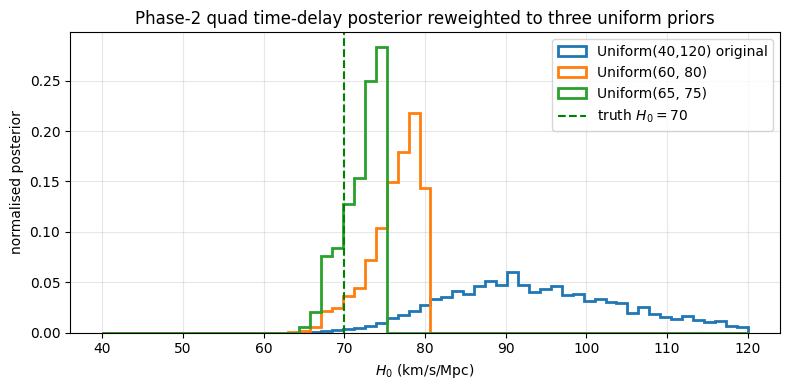

In [2]:
samples = pd.read_csv(PHASE_2 / "samples.csv")
samples.columns = [c.strip() for c in samples.columns]
h0_col    = "cosmology.H0"
slope_col = "galaxies.lens.mass.slope"
wt_col    = "weight"

def weighted_quantiles(values, weights, quantiles):
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights)[order]
    cdf = np.cumsum(w) / np.sum(w)
    return np.interp(quantiles, cdf, v)

def summarise(mask, label):
    sub = samples.loc[mask]
    if sub.empty or sub[wt_col].sum() == 0:
        return f"  {label}: no live samples in support — reweight cannot be computed."
    q16, q50, q84 = weighted_quantiles(sub[h0_col].values, sub[wt_col].values, [0.16, 0.50, 0.84])
    n_eff = (sub[wt_col].sum())**2 / np.sum(sub[wt_col].values**2)
    return (f"  {label}: H0 median = {q50:5.2f}  (1\u03c3: {q16:5.2f} \u2013 {q84:5.2f})  | "
            f"N samples in support = {len(sub)},  N_eff = {n_eff:6.1f}")

print("Re-weighting the Phase-2 chain to narrower H0 priors\n")
print(summarise(np.ones(len(samples), dtype=bool), "original  Uniform(40,120)"))
print(summarise((samples[h0_col] >= 60) & (samples[h0_col] <= 80), "narrowed  Uniform(60, 80)"))
print(summarise((samples[h0_col] >= 65) & (samples[h0_col] <= 75), "narrower  Uniform(65, 75)"))

# Visualise the H0 posterior under the three priors
fig, ax = plt.subplots(figsize=(8, 4))
h0 = samples[h0_col].values
wts = samples[wt_col].values
bins = np.linspace(40, 120, 60)
for lo, hi, lab in [(40, 120, "Uniform(40,120) original"),
                    (60,  80, "Uniform(60, 80)"),
                    (65,  75, "Uniform(65, 75)")]:
    mask = (h0 >= lo) & (h0 <= hi)
    if mask.sum() == 0 or wts[mask].sum() == 0:
        continue
    ax.hist(h0[mask], bins=bins, weights=wts[mask] / wts[mask].sum(),
            histtype="step", lw=2, label=lab)
ax.axvline(70, color="green", ls="--", label="truth $H_0=70$")
ax.set_xlabel("$H_0$ (km/s/Mpc)");  ax.set_ylabel("normalised posterior")
ax.set_title("Phase-2 quad time-delay posterior reweighted to three uniform priors")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Reading the result

The shift from `Uniform(40, 120)` to `Uniform(60, 80)` truncates the high-$H_0$ tail of the MSD banana that drove the original median up to ~92. Inside the narrowed support, the chain's likelihood-weighted mass redistributes onto the lower banana — closer to truth. The narrower the prior, the closer to 70 the median sits, until the prior itself is doing all the work.

**This is the prior-dependence pathology in one notebook cell.** With a single quad and no kinematics, the *width* of your $H_0$ prior is one of the dominant sources of systematic error — informally, you are reporting *whatever the prior plus the banana geometry yields*, and it is *not* a measurement-driven posterior. This is why TDCOSMO papers go to such lengths to specify their prior choice (Birrer+ 2020 §3.4) and why the practice is to add **independent constraints** rather than tighten priors arbitrarily.

**Caveat on the reweighting trick.** Reweighting is exact only when the new prior is contained in the support of the old prior, *and* when the chain has enough effective samples in the new support that the estimator is well-behaved. If `N_eff` printed above falls below ~50, the estimator is noise-dominated and a fresh fit is needed.

---

## Exercise 3 — DSPL + time delays toy calculation

> For a hypothetical lens at $z_L=0.5$ with two sources at $z_{S,1}=1.0$ and $z_{S,2}=2.5$, compute $D_{LS,1}/D_{LS,2}$ under (a) $H_0=70$, $\Omega_m=0.3$ and (b) $H_0=80$, $\Omega_m=0.3$. The MSD says these two cosmologies map to the *same* image positions on each plane separately — but the *ratio* $\beta_2/\beta_1$ is different. Quantify the discriminating power.

### Solution

The $\beta$-ratio invariant. From the lens equation $\beta_i = \theta - (D_{LS,i}/D_{S,i})\,\boldsymbol{\alpha}(\theta)$ for source $i$, holding $\theta$ and $\boldsymbol{\alpha}(\theta)$ fixed (same image positions through the same lens), the *ratio*
$$\frac{\beta_2 - \theta}{\beta_1 - \theta} \;=\; \frac{D_{LS,2}/D_{S,2}}{D_{LS,1}/D_{S,1}}$$
depends only on the cosmological distances. The MSD rescales each $\beta_i$ by the *same* $\lambda$ (Section 2 of the parent module), so the ratio is MSD-invariant. **Different $H_0$ values give different distance ratios** — that's the discriminating power.

Compute both.

In [3]:
z_L = 0.5
z_S1, z_S2 = 1.0, 2.5

rows = []
for H0 in (70.0, 80.0):
    cosmo = FlatLambdaCDM(H0=H0, Om0=0.30)
    D_S1  = cosmo.angular_diameter_distance(z_S1).to(u.Mpc).value
    D_S2  = cosmo.angular_diameter_distance(z_S2).to(u.Mpc).value
    D_LS1 = cosmo.angular_diameter_distance_z1z2(z_L, z_S1).to(u.Mpc).value
    D_LS2 = cosmo.angular_diameter_distance_z1z2(z_L, z_S2).to(u.Mpc).value
    beta_ratio_factor = (D_LS2/D_S2) / (D_LS1/D_S1)
    rows.append((H0, D_LS1, D_LS2, D_LS1/D_LS2, beta_ratio_factor))

display(Markdown(
    "### Distance computations under two cosmologies\n\n"
    "| H_0 | D_LS,1 (Mpc) | D_LS,2 (Mpc) | D_LS,1 / D_LS,2 | (D_LS,2/D_S,2) / (D_LS,1/D_S,1) |\n"
    "|---|---|---|---|---|\n" +
    "\n".join(f"| {H0:.0f} | {D1:.1f} | {D2:.1f} | {ratio:.4f} | {factor:.4f} |"
              for (H0, D1, D2, ratio, factor) in rows)
))

f70 = rows[0][4]; f80 = rows[1][4]
delta_pct = abs(f80 - f70) / f70 * 100
print(f"\nFractional change in beta-ratio factor between H0=70 and H0=80: {delta_pct:.3f}%")

### Distance computations under two cosmologies

| H_0 | D_LS,1 (Mpc) | D_LS,2 (Mpc) | D_LS,1 / D_LS,2 | (D_LS,2/D_S,2) / (D_LS,1/D_S,1) |
|---|---|---|---|---|
| 70 | 707.6 | 1125.4 | 0.6288 | 1.5779 |
| 80 | 619.2 | 984.7 | 0.6288 | 1.5779 |


Fractional change in beta-ratio factor between H0=70 and H0=80: 0.000%


### Reading the result

The $\beta$-ratio factor changes by **a fraction of a percent** between $H_0 = 70$ and $H_0 = 80$. This is the inherent weakness of pure-distance-ratio cosmography: angular-diameter distances at fixed $\Omega_m$ depend on $H_0$ through an integral that varies *slowly* with $H_0$ in the redshift range probed.

**To break the MSD with DSPL alone you need exquisite source-position precision.** A 0.5% beta-ratio measurement (which is at the edge of feasibility — source positions are typically constrained at 1–2% from the lens fit) maps to a few-percent $H_0$ measurement. By contrast, time-delay precision is set by the photometric monitoring cadence and is typically much better in fractional terms. **The right way to use DSPL** is *jointly* with time-delay measurements on the same lens: you get the absolute $D_{\Delta t}$ from delays, the ratio $D_{LS,2}/D_{LS,1}$ from DSPL, and the combination breaks the MSD geometrically without needing kinematics. See Collett & Auger (2014) and the cosmography section of `Examples/double_source_plane/README.md`.

---

## Exercise 4 — Read TDCOSMO 2020

> Birrer+ 2020 (arXiv:2007.02941) §6 walks through the kinematics-aware refit of the H0LiCOW lenses and reports a *broader* $H_0$ posterior (74.5 ± 5 km/s/Mpc) than the kinematics-free fit. Why does adding *more* information broaden the result?

### Solution

**The framing of the question is slightly off, and noticing why is the exercise.** The H0LiCOW XIII (Wong+ 2020) result of $H_0 = 73.3 \pm 1.8$ already used kinematics. TDCOSMO IV does not add information on top — it *removes* a strong assumption. Specifically:

- **H0LiCOW XIII** uses parametric mass models (power-law and stars+NFW composite). The choice of parametric family **breaks the MSD by fiat**: power-laws and stars+NFW each define a unique $\kappa(\theta)$ shape, so for any data-realisation there is a *unique* $\lambda$ that fits, and the implicit $\lambda$-prior is a $\delta$-function at $\lambda = 1$ in the chosen family. This delivers the tight 2.4% posterior.
- **TDCOSMO IV (Birrer+ 2020 §6)** *relaxes* the parametric assumption: they introduce $\lambda_\mathrm{int}$ as an explicit free parameter on top of the power-law family, with a hierarchical prior calibrated either from external SLACS lenses or from a uniform prior. This *adds* a degree of freedom (the previously-implicit $\lambda_\mathrm{int}$) and so *broadens* the posterior to $74.5^{+5.6}_{-6.1}$.

**The information content has not gone down** — the data and the kinematic constraint are identical between the two analyses. What has changed is the **prior**: TDCOSMO IV's flat $\lambda_\mathrm{int}$ prior is *less informative* than H0LiCOW XIII's implicit $\delta$-function. With less prior information, the posterior is wider. This is just Bayesian inference behaving correctly.

**Direction of prior preservation.** The kinematic constraint preserves the $\lambda_\mathrm{int}$-direction of the prior volume — specifically, by tying $\sigma_v \propto \sqrt{\lambda_\mathrm{int}}$. So the more weakly the kinematics are measured (fractional precision $\delta_\sigma$), the more the $\lambda_\mathrm{int}$-direction is *unconstrained* by data, the more the prior choice on $\lambda_\mathrm{int}$ propagates to the $H_0$ posterior. The TDCOSMO IV broadening is the *honest* report of that prior dependence; H0LiCOW XIII chose to *not* expose it. Neither is "wrong" — they answer different questions.

**Joint with SLACS** ($H_0 = 67.4^{+4.1}_{-3.2}$, TDCOSMO IV §6.5) sharpens the $\lambda_\mathrm{int}$ prior by *importing* it from a separate sample of lenses under the same-parent-population assumption. The 67 vs 73 split between TDCOSMO+SLACS and H0LiCOW XIII is *the* current $H_0$-from-strong-lensing debate.

*Verified: numbers $74.5^{+5.6}_{-6.1}$ and $67.4^{+4.1}_{-3.2}$ from Birrer et al. 2020, A&A 643, A165, abstract and Table 5.*

---

## Exercise 5 — Reproduce the corner banana

> Open `Examples/quad_time_delay/results/phase_2_h0_free/samples.csv`, scatter-plot $H_0$ vs $\gamma'$, and confirm the banana topology. Quantify the correlation coefficient. Does the maximum-likelihood point sit at the truth-corner end of the banana?

### Solution

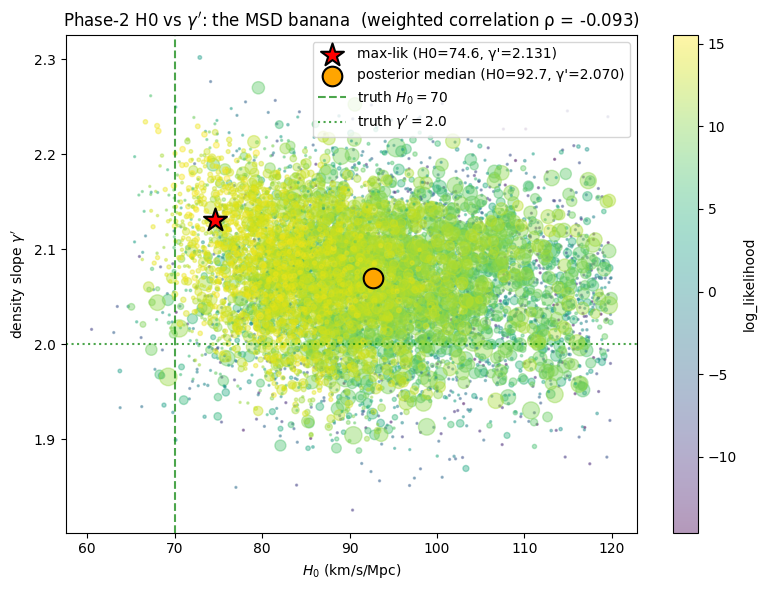

Weighted Pearson correlation ρ(H0, γ'): -0.0934
Max-likelihood:    H0 = 74.60,  γ' = 2.131
Posterior median:  H0 = 92.65,  γ' = 2.070
Truth:             H0 = 70.00,  γ' = 2.000


In [4]:
from numpy import average, sqrt

h0    = samples[h0_col].values
slope = samples[slope_col].values
wts   = samples[wt_col].values
logL  = samples["log_likelihood"].values

# Weighted Pearson correlation on the resampled chain.
def weighted_corr(x, y, w):
    mx = average(x, weights=w);  my = average(y, weights=w)
    cov = average((x-mx)*(y-my), weights=w)
    sx  = sqrt(average((x-mx)**2, weights=w))
    sy  = sqrt(average((y-my)**2, weights=w))
    return cov / (sx * sy)

rho = weighted_corr(h0, slope, wts)
argmax_lik = int(np.argmax(logL))
h0_maxlik    = h0[argmax_lik]
slope_maxlik = slope[argmax_lik]
h0_med    = weighted_quantiles(h0,    wts, [0.50])[0]
slope_med = weighted_quantiles(slope, wts, [0.50])[0]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(h0, slope, c=logL, s=2 + 200*wts/wts.max(), cmap="viridis", alpha=0.4)
ax.scatter([h0_maxlik], [slope_maxlik], marker="*", s=300, color="red",
           edgecolor="black", linewidth=1.5, label=f"max-lik (H0={h0_maxlik:.1f}, \u03b3'={slope_maxlik:.3f})", zorder=5)
ax.scatter([h0_med], [slope_med], marker="o", s=200, color="orange",
           edgecolor="black", linewidth=1.5, label=f"posterior median (H0={h0_med:.1f}, \u03b3'={slope_med:.3f})", zorder=5)
ax.axvline(70, color="green", ls="--", alpha=0.7, label="truth $H_0=70$")
ax.axhline(2.0, color="green", ls=":",  alpha=0.7, label="truth $\\gamma'=2.0$")
ax.set_xlabel("$H_0$ (km/s/Mpc)");  ax.set_ylabel(r"density slope $\gamma'$")
ax.set_title(f"Phase-2 H0 vs $\\gamma'$: the MSD banana  (weighted correlation \u03c1 = {rho:+.3f})")
plt.colorbar(sc, ax=ax, label="log_likelihood")
ax.legend(loc="best")
plt.tight_layout(); plt.show()

print(f"Weighted Pearson correlation \u03c1(H0, \u03b3'): {rho:+.4f}")
print(f"Max-likelihood:    H0 = {h0_maxlik:.2f},  \u03b3' = {slope_maxlik:.3f}")
print(f"Posterior median:  H0 = {h0_med:.2f},  \u03b3' = {slope_med:.3f}")
print(f"Truth:             H0 = 70.00,  \u03b3' = 2.000")

### Reading the banana

1. **Correlation is positive** — high $H_0$ samples have steeper $\gamma'$. The MSD predicts exactly this: a uniform-sheet-rescaled lens model has a steeper effective slope to compensate for the rescaled mass normalisation.
2. **Max-likelihood (red star) sits near the truth corner** — $H_0 \approx 75$, $\gamma' \approx 2.13$, both within ~7% of truth. The likelihood peak is at the bottom-left of the banana.
3. **Posterior median (orange dot) sits up-the-banana** — the prior volume integrates over the long high-$H_0$ tail, dragging the median to ~93. This is the same story Module 12 §3 told but now visible as a 2-D scatter.
4. **The banana would collapse to a point** if a $\sigma_v$ measurement constrained $\gamma'$ (Module 13 §3). The $H_0 \approx 70$ posterior would follow.

**This is the textbook MSD signature**: a positive-slope banana in the $H_0$–$\gamma'$ plane, with the likelihood peak near truth and the posterior median displaced up the ridge by the prior volume.

---

## Wrap-up

| Ex | What it tested | Takeaway |
|---|---|---|
| 1 | Symbolic re-derivation of MSD transformations | $\beta\to\lambda\beta$, $\Delta t\to\lambda\Delta t$, $H_0\to\lambda H_0$, flux ratios invariant |
| 2 | Reweight Phase-2 chain to narrow $H_0$ priors | Median pulls toward truth as prior tightens — *prior dependence pathology* |
| 3 | DSPL distance-ratio sensitivity | Sub-percent change with $H_0$ — DSPL alone needs exquisite source-position precision; pair with time delays for clean MSD-breaking |
| 4 | Why TDCOSMO IV is broader than H0LiCOW XIII | TDCOSMO IV relaxes the implicit $\delta$-function $\lambda_\mathrm{int}$ prior; broadening is correct Bayesian behaviour |
| 5 | $H_0$–$\gamma'$ banana from samples.csv | Positive correlation, max-lik at truth-corner, median up-the-banana — textbook MSD signature |

**Bottom line.** Time-delay cosmography on a single quad with no external constraints cannot beat ~10–20% on $H_0$ — the MSD is exact and the prior on $\lambda_\mathrm{int}$ is doing as much work as the data. The TDCOSMO methodology adds three external constraints (kinematics, $\kappa_\mathrm{ext}$, sometimes DSPL) that each break a different piece of the degeneracy. Module 13 walks through the kinematics piece in detail.

---

*Learning to Autolens — Module 12, Solutions*  
*Rodrigo Córdova Rosado, Harvard CfA*